In [1]:
# confirm environment (C:\Users\mitch\source\repos\mtg_ai\.venv\Scripts\python.exe)

import sys
print(sys.executable)

C:\Users\mitch\source\repos\mtg_ai\.venv\Scripts\python.exe


In [8]:
# Imports & display config

import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# Make pandas usable for wide MTG data
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 0)

PROJECT_ROOT = Path("..").resolve()
DATA = PROJECT_ROOT / "data" / "processed"

In [5]:
# Load datasets

cards_core = pd.read_parquet(DATA / "cards_core.parquet")
cards_enriched = pd.read_parquet(DATA / "cards_enriched.parquet")
type_features = pd.read_parquet(DATA / "type_features.parquet")
oracle_tokens = pd.read_parquet(DATA / "oracle_tokens.parquet")
clusters = pd.read_parquet(DATA / "oracle_clusters.parquet")

print("Loaded:")
print("cards_core:", cards_core.shape)
print("cards_enriched:", cards_enriched.shape)
print("type_features:", type_features.shape)
print("oracle_tokens:", oracle_tokens.shape)
print("clusters:", clusters.shape)

Loaded:
cards_core: (36708, 19)
cards_enriched: (36708, 23)
type_features: (36708, 8)
oracle_tokens: (36708, 5)
clusters: (36708, 2)


In [6]:
cards = cards_enriched.merge(clusters, on="id", how="left")
cards = cards.merge(
    oracle_tokens[["id", "oracle_tokens"]],
    on="id",
    how="left"
)

print(cards.shape)
cards.head(3)

(36708, 25)


,id,oracle_id,name,released_at,lang,layout,type_line,oracle_text,mana_cost,colors,color_identity,keywords,legalities,set,set_name,rarity,cmc,power,toughness,oracle_text_norm,basic_types,super_types,sub_types,cluster,oracle_tokens
0,a471b306-4941-4e46-a0cb-d92895c16f8a,00037840-6089-42ec-8c5c-281f9f474504,"Nissa, Worldsoul Speaker",2025-02-14,en,normal,Legendary Creature — Elf Druid,"Landfall — Whenever a land you control enters, you get {E}{E} (two energy counters).\nYou may pay eight {E} rather t...",{3}{G},[G],[G],[Landfall],"{'alchemy': 'not_legal', 'brawl': 'not_legal', 'commander': 'legal', 'duel': 'legal', 'future': 'not_legal', 'gladia...",drc,Aetherdrift Commander,rare,4.0,3,3,"Landfall — Whenever a land you control enters, you get {E}{E} (two energy counters).\nYou may pay eight {E} rather t...",[Creature],[Legendary],"[Elf, Druid]",148,"[landfall, —, whenever, a, land, you, control, enters, you, get, MANA_SYMBOL, MANA_SYMBOL, (two, energy, counters), ..."
1,6b7baaa7-67f2-4902-a4c1-761d58cce1d4,000492bf-7eaa-4939-a51c-4eef74e4c1d1,Mine Security,2025-08-19,en,normal,Creature — Kavu Soldier,"Trample\nWhen this creature enters, conjure a card named Flametongue Kavu into the top eight cards of your library a...",{1}{R},[R],[R],"[Trample, Conjure]","{'alchemy': 'legal', 'brawl': 'legal', 'commander': 'not_legal', 'duel': 'not_legal', 'future': 'not_legal', 'gladia...",yeoe,Alchemy: Edge of Eternities,uncommon,2.0,3,1,"Trample\nWhen this creature enters, conjure a card named Flametongue Kavu into the top eight cards of your library a...",[Creature],[],"[Kavu, Soldier]",122,"[trample, NEWLINE, when, this, creature, enters, conjure, a, card, named, flametongue, kavu, into, the, top, eight, ..."
2,86bf43b1-8d4e-4759-bb2d-0b2e03ba7012,0004ebd0-dfd6-4276-b4a6-de0003e94237,Static Orb,2001-04-11,en,normal,Artifact,"As long as this artifact is untapped, players can't untap more than two permanents during their untap steps.",{3},[],[],[],"{'alchemy': 'not_legal', 'brawl': 'not_legal', 'commander': 'legal', 'duel': 'legal', 'future': 'not_legal', 'gladia...",7ed,Seventh Edition,rare,3.0,None,None,"As long as this artifact is untapped, players can't untap more than two permanents during their untap steps.",[Artifact],[],[],91,"[as_long_as, this, artifact, is, untapped, players, can't, untap, more, than, two, permanents, during, their, untap,..."


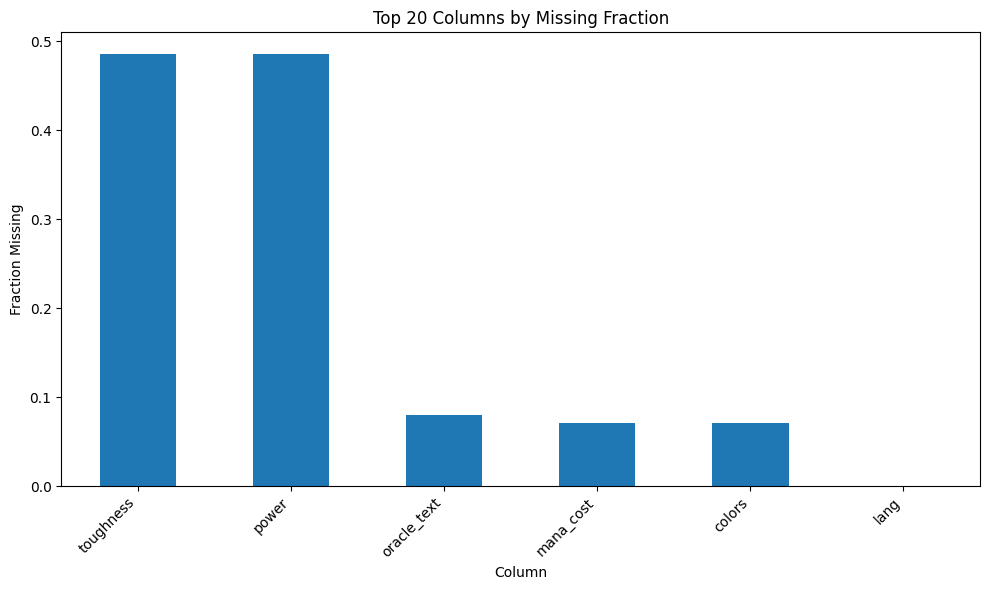

In [10]:
missing = (
    cards.isna()
    .mean()
    .sort_values(ascending=False)
    .head(6)
)

plt.figure(figsize=(10, 6))
missing.plot(kind="bar")
plt.title("Top 20 Columns by Missing Fraction")
plt.ylabel("Fraction Missing")
plt.xlabel("Column")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

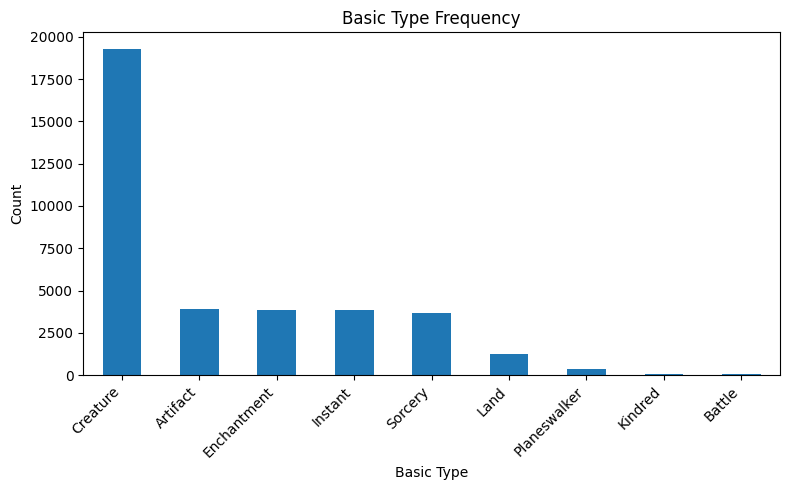

In [11]:
type_counts = (
    type_features["basic_types"]
    .explode()
    .value_counts()
)

plt.figure(figsize=(8, 5))
type_counts.plot(kind="bar")
plt.title("Basic Type Frequency")
plt.ylabel("Count")
plt.xlabel("Basic Type")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [18]:
cards["cmc"].dtype

dtype('float64')

In [19]:
cards["cmc"].unique()[:10]

array([ 4.,  2.,  3.,  1.,  5.,  0.,  7.,  8.,  6., 12.])

In [20]:
cards["cmc"].describe()

count      36708.000000
mean          30.183053
std         5219.373681
min            0.000000
25%            2.000000
50%            3.000000
75%            4.000000
max      1000000.000000
Name: cmc, dtype: float64

In [23]:
cards[["name", "cmc"]].head(5)

,name,cmc
0,"Nissa, Worldsoul Speaker",4.0
1,Mine Security,2.0
2,Static Orb,3.0
3,Sensory Deprivation,1.0
4,Kavaron Consumed,5.0


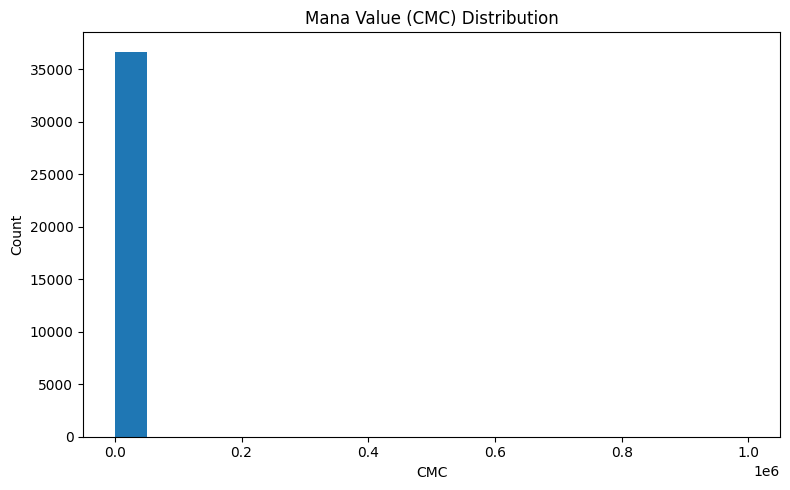

In [25]:
plt.figure(figsize=(8, 5))
cards["cmc"].dropna().plot(kind="hist", bins=20)
plt.title("Mana Value (CMC) Distribution")
plt.xlabel("CMC")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

[4. 2. 3. 1. 5. 2. 2. 1. 2. 4. 3. 5. 2. 1. 0. 3. 2. 3. 3. 7.]
0.0 1000000.0


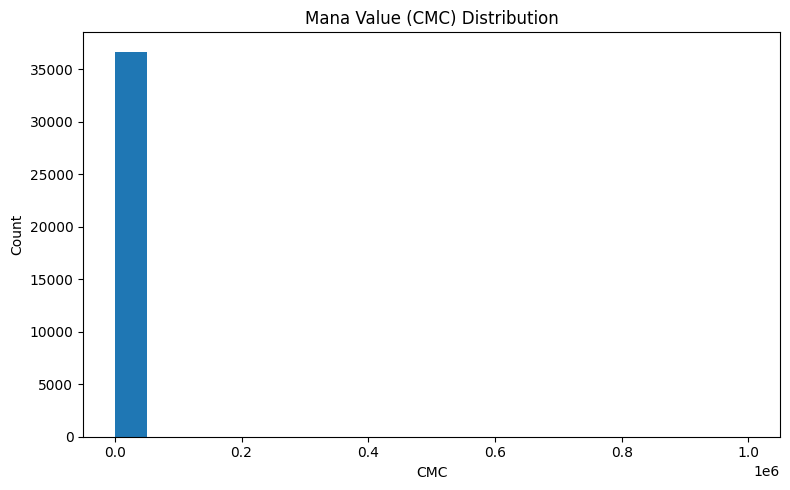

In [26]:
cmc_values = cards["cmc"].dropna().astype("float64").to_numpy()

print(cmc_values[:20])
print(cmc_values.min(), cmc_values.max())

plt.figure(figsize=(8, 5))
plt.hist(cmc_values, bins=20)
plt.title("Mana Value (CMC) Distribution")
plt.xlabel("CMC")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

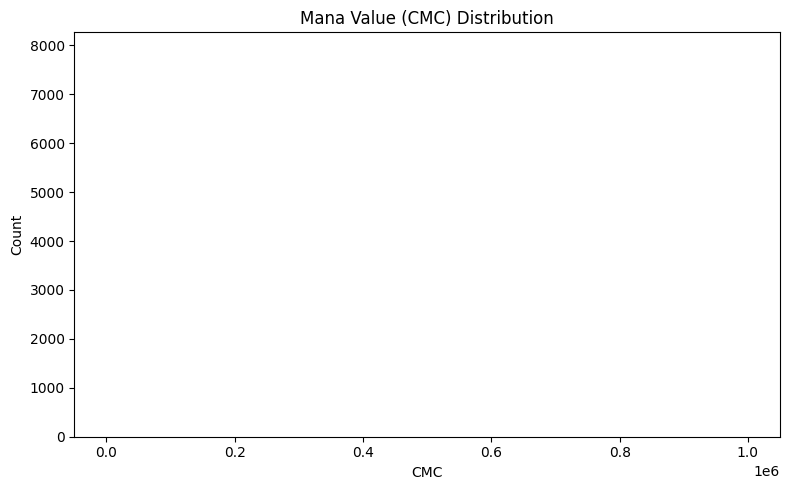

In [27]:
cmc_values = cards["cmc"].dropna().astype("float64").to_numpy()

bins = range(0, int(cmc_values.max()) + 2)

plt.figure(figsize=(8, 5))
plt.hist(cmc_values, bins=bins)
plt.title("Mana Value (CMC) Distribution")
plt.xlabel("CMC")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [29]:
cmc_counts = (
    cards["cmc"]
    .dropna()
    .round(0)
    .astype(int)
    .value_counts()
    .sort_index()
)

cmc_counts

cmc
0          5162
1          3204
2          6917
3          7874
4          6210
5          3909
6          2040
7           869
8           316
9           105
10           53
11           20
12           16
13            2
14            1
15            8
16            1
1000000       1
Name: count, dtype: int64

In [15]:
# Clean head() views (select columns)

cards_enriched[
    [
        "name",
        "type_line",
        "basic_types",
        "sub_types",
        "cmc",
        "oracle_text_norm",
    ]
].head(10)

In [17]:
# Inspect tokenization quality

oracle_tokens[
    ["name", "oracle_text_norm", "oracle_tokens"]
].sample(5, random_state=42)

,name,oracle_text_norm,oracle_tokens
20917,Caravan Vigil,"Search your library for a basic land card, reveal it, put it into your hand, then shuffle.\nMorbid — You may put that card onto the battlefield instead of putting it into your hand if a creature died this turn.","[search, your, library, for, a, basic, land, card, reveal, it, put, it, into, your, hand, then, shuffle, NEWLINE, morbid, —, you_may, put, that, card, onto, the, battlefield, instead, of, putting, it, into, your, hand, if, a, creature, died, this, turn]"
18857,Bishop's Soldier,Lifelink (Damage dealt by this creature also causes you to gain that much life.),"[lifelink, (damage, dealt, by, this, creature, also, causes, you, to, gain, that, much, life, )]"
27507,Raging Kronch,This creature can't attack alone.,"[this, creature, can't, attack, alone]"
35527,"Gonti, Night Minister // Gonti, Night Minister",,[]
29950,Dragon-Style Twins,"Double strike\nProwess (Whenever you cast a noncreature spell, this creature gets +1/+1 until end of turn.)","[double, strike, NEWLINE, prowess, (whenever, you, cast, a, noncreature, spell, this, creature, gets, +1/+1, until_end_of_turn, )]"


In [19]:
# Look at a single known card

oracle_tokens[oracle_tokens["name"] == "Lightning Bolt"][
    ["oracle_text_norm", "oracle_tokens"]
]

,oracle_text_norm,oracle_tokens
9748,this card deals 3 damage to any target.,"[this, card, deals, NUM:3, damage, to, any, target]"


In [21]:
# Inspect type parsing edge cases

type_features.sample(10, random_state=1)[
    ["name", "type_line", "basic_types", "super_types", "sub_types"]
]

,name,type_line,basic_types,super_types,sub_types
18046,Working Stiff,Creature — Mummy,[Creature],[],[Mummy]
2363,"Appa, Aang's Companion // Appa, Aang's Companion",Card // Card,[],"[Card, Card]",[]
15175,Flight,Enchantment — Aura,[Enchantment],[],[Aura]
8632,Fleshtaker // Fleshtaker,Card // Card,[],"[Card, Card]",[]
22145,Drone,Token Artifact Creature — Drone,"[Artifact, Creature]",[Token],[Drone]
13942,Nekrataal Avatar,Vanguard,[],[Vanguard],[]
12824,Chandra's Spitfire,Creature — Elemental,[Creature],[],[Elemental]
15114,Guise of Fire,Enchantment — Aura,[Enchantment],[],[Aura]
32487,Traumatize,Sorcery,[Sorcery],[],[]
8621,Auratouched Mage,Creature — Human Wizard,[Creature],[],"[Human, Wizard]"


In [25]:
# Test problem children

type_features[type_features["name"].isin([
    "Dryad Arbor",
    "Urza, Lord High Artificer",
    "Fire // Ice",
    "Westvale Abbey"
])][
    ["name", "type_line", "basic_types", "super_types", "sub_types", "type_faces"]
]

,name,type_line,basic_types,super_types,sub_types,type_faces
24929,Fire // Ice,Instant // Instant,"[Instant, Instant]",[],[],"[{'basic_types': ['Instant'], 'raw_face_type_line': 'Instant', 'sub_types': [], 'super_types': []}, {'basic_types': ['Instant'], 'raw_face_type_line': 'Instant', 'sub_types': [], 'super_types': []}]"
33284,"Urza, Lord High Artificer",Legendary Creature — Human Artificer,[Creature],[Legendary],"[Human, Artificer]","[{'basic_types': ['Creature'], 'raw_face_type_line': 'Legendary Creature — Human Artificer', 'sub_types': ['Human', 'Artificer'], 'super_types': ['Legendary']}]"
33439,Dryad Arbor,Land Creature — Forest Dryad,"[Land, Creature]",[],"[Forest, Dryad]","[{'basic_types': ['Land', 'Creature'], 'raw_face_type_line': 'Land Creature — Forest Dryad', 'sub_types': ['Forest', 'Dryad'], 'super_types': []}]"


In [27]:
# Merge clusters for inspection

clusters = pd.read_parquet(DATA / "oracle_clusters.parquet")

cards_with_clusters = (
    cards_enriched
    .merge(clusters, on="id", how="left")
)

cards_with_clusters[["name", "type_line", "cluster"]].head()

,name,type_line,cluster
0,"Nissa, Worldsoul Speaker",Legendary Creature — Elf Druid,148
1,Mine Security,Creature — Kavu Soldier,122
2,Static Orb,Artifact,91
3,Sensory Deprivation,Enchantment — Aura,54
4,Kavaron Consumed,Sorcery,64


In [29]:
# Inspect a single cluster

cluster_id = 17  # change this

cards_with_clusters[cards_with_clusters["cluster"] == cluster_id][
    ["name", "type_line", "oracle_text_norm"]
].head(20)

,name,type_line,oracle_text_norm
64,Dungeon Delver,Legendary Enchantment — Background,"Commander creatures you own have ""Room abilities of dungeons you own trigger an additional time."""
75,Brawn,Creature — Incarnation,"Trample\nAs long as this card is in your graveyard and you control a Forest, creatures you control have trample."
116,Furnace Oriflamme,Enchantment,"Creatures you control get +1/+0.\nIf you're on the Mirran team, creatures you control have haste.\nIf you're on the Phyrexian team, creatures you control have trample."
1464,Hag of Mage's Doom,Creature — Hag Warlock,"Warlocks you control have ""Ward—Pay 2 life."""
2682,Cyberdrive Awakener,Artifact Creature — Construct,"Flying\nOther artifact creatures you control have flying.\nWhen this creature enters, each noncreature artifact you control becomes a 4/4 artifact creature until end of turn."
2695,"Smellerbee, Rebel Fighter",Legendary Creature — Human Rebel Ally,"First strike\nOther creatures you control have haste.\nWhenever Smellerbee attacks, you may discard your hand. If you do, draw cards equal to the number of attacking creatures."
2711,"Maha, Its Feathers Night",Legendary Creature — Elemental Bird,"Flying, trample\nWard—Discard a card.\nCreatures your opponents control have base toughness 1."
3162,Orim,Vanguard,Creatures you control have reach.
3392,"Elspeth, Knight-Errant Emblem",Emblem — Elspeth,"Artifacts, creatures, enchantments, and lands you control have indestructible."
3657,The Kami Knight,Legendary Creature — Spirit Warrior,Other creatures you control gain all bonuses conferred by equipment attached to this creature.\nCreatures you control can't be goaded.


In [31]:
# Cluster size distribution

cards_with_clusters["cluster"].value_counts().head(20)

cluster
4      3896
61      493
70      431
96      409
99      388
67      387
12      372
68      336
43      326
24      321
22      313
167     309
126     307
2       299
79      292
109     291
195     290
86      290
130     288
23      286
Name: count, dtype: int64